In [1]:
from sklearn.datasets import fetch_openml

# Chargement du dataset avec ses métadonnées officielles
titanic = fetch_openml('titanic', version=1, as_frame=True)

# Afficher la description experte globale
print(titanic.DESCR)

# Afficher les détails des colonnes (features)
print(titanic.details)

**Author**: Frank E. Harrell Jr., Thomas Cason  
**Source**: [Vanderbilt Biostatistics](http://biostat.mc.vanderbilt.edu/wiki/pub/Main/DataSets/titanic.html)  
**Please cite**:   

The original Titanic dataset, describing the survival status of individual passengers on the Titanic. The titanic data does not contain information from the crew, but it does contain actual ages of half of the passengers. The principal source for data about Titanic passengers is the Encyclopedia Titanica. The datasets used here were begun by a variety of researchers. One of the original sources is Eaton & Haas (1994) Titanic: Triumph and Tragedy, Patrick Stephens Ltd, which includes a passenger list created by many researchers and edited by Michael A. Findlay.

Thomas Cason of UVa has greatly updated and improved the titanic data frame using the Encyclopedia Titanica and created the dataset here. Some duplicate passengers have been dropped, many errors corrected, many missing ages filled in, and new variable

In [2]:
from sklearn.datasets import fetch_openml

# Charger le dataset via son ID (40945 d'après ton résultat)
dataset = fetch_openml(data_id=40945, as_frame=True, parser='auto')

# Afficher la description experte automatiquement
print("=== DESCRIPTION EXPERTE ===")
print(dataset.DESCR)

# Afficher les métadonnées techniques (ID, Version, Date)
print("\n=== MÉTADONNÉES ===")
for key, value in dataset.details.items():
    print(f"{key}: {value}")

=== DESCRIPTION EXPERTE ===
**Author**: Frank E. Harrell Jr., Thomas Cason  
**Source**: [Vanderbilt Biostatistics](http://biostat.mc.vanderbilt.edu/wiki/pub/Main/DataSets/titanic.html)  
**Please cite**:   

The original Titanic dataset, describing the survival status of individual passengers on the Titanic. The titanic data does not contain information from the crew, but it does contain actual ages of half of the passengers. The principal source for data about Titanic passengers is the Encyclopedia Titanica. The datasets used here were begun by a variety of researchers. One of the original sources is Eaton & Haas (1994) Titanic: Triumph and Tragedy, Patrick Stephens Ltd, which includes a passenger list created by many researchers and edited by Michael A. Findlay.

Thomas Cason of UVa has greatly updated and improved the titanic data frame using the Encyclopedia Titanica and created the dataset here. Some duplicate passengers have been dropped, many errors corrected, many missing ages

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None
             count        mean         std   min       25%       50%    75%  \
PassengerId  891.0  446.000000  257.353842  1.00  223.5000  446.0000  668.5   
Survived     891.0    0.383838    0.486592  0.00    0.0000    0.0000    1.0   
Pc

C:\Users\solta\AppData\Local\Temp\ipykernel_4632\2760997609.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Survived', data=df, palette='viridis')


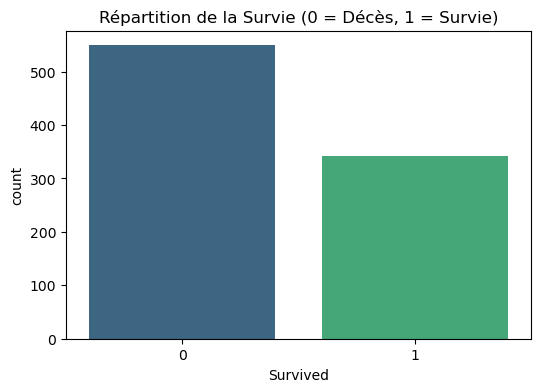

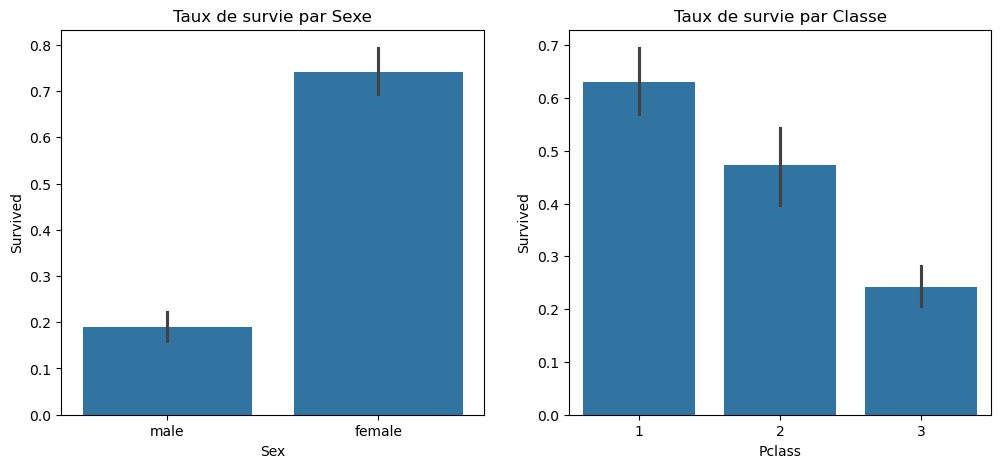

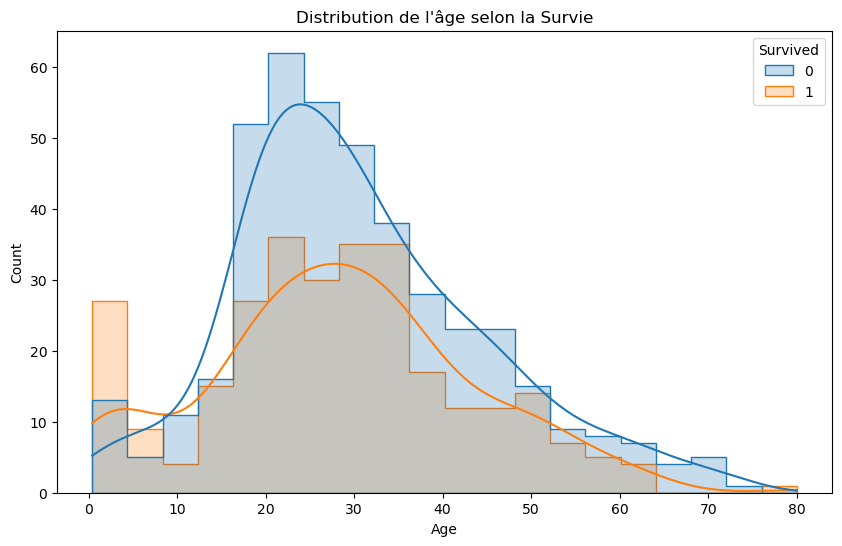

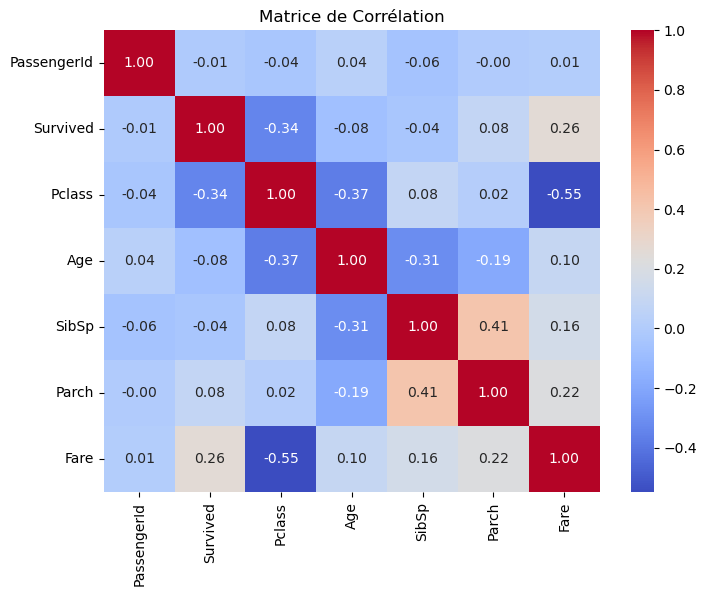

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Chargement des données brutes (avant transformations)
df = pd.read_csv("titanic_train.csv")

# --- ÉTAPE 1 : Vue d'ensemble ---
print(df.info())
print(df.describe().T)
print(f"\nValeurs manquantes :\n{df.isnull().sum()}")

# --- ÉTAPE 2 : Analyse de la Variable Cible (Survived) ---
plt.figure(figsize=(6, 4))
sns.countplot(x='Survived', data=df, palette='viridis')
plt.title('Répartition de la Survie (0 = Décès, 1 = Survie)')
plt.show()

# --- ÉTAPE 3 : Analyse des variables catégoriques ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Survie par Sexe
sns.barplot(x='Sex', y='Survived', data=df, ax=axes[0])
axes[0].set_title('Taux de survie par Sexe')

# Survie par Classe
sns.barplot(x='Pclass', y='Survived', data=df, ax=axes[1])
axes[1].set_title('Taux de survie par Classe')
plt.show()

# --- ÉTAPE 4 : Analyse des variables numériques (Âge) ---
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Age', hue='Survived', kde=True, element="step")
plt.title('Distribution de l\'âge selon la Survie')
plt.show()

# --- ÉTAPE 5 : Corrélation entre les variables ---
# On ne garde que les colonnes numériques pour la corrélation
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matrice de Corrélation')
# AJOUTER CETTE LIGNE :
plt.savefig("matrice_correlation.png", dpi=300, bbox_inches='tight')
plt.show()

In [4]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# 1. Chargement
titanic_df = pd.read_csv("titanic_train.csv")

# 2. Feature Engineering : Création de FamilyNb et Alone
# Justification : Fusion de variables corrélées (SibSp/Parch) pour capturer l'impact social global.
titanic_df['FamilyNb'] = titanic_df['SibSp'] + titanic_df['Parch']
titanic_df['Alone'] = (titanic_df['FamilyNb'] == 0).astype(int)

# 3. Encodage : Sex + Embarked
# Justification : Conversion des catégories textuelles en vecteurs numériques pour le calcul de distance.
sex_df = pd.get_dummies(titanic_df['Sex'], prefix='sex', drop_first=True)
embarked_df = pd.get_dummies(titanic_df['Embarked'], prefix='embarked', dummy_na=False)
titanic_df = pd.concat([titanic_df, embarked_df, sex_df], axis=1)

# 4. Nettoyage : Suppression des colonnes bruyantes ou redondantes
# Justification : Éliminer les identifiants uniques et les fuites de données (Fare est porté par Pclass).
cols_to_drop = ['PassengerId', 'Name', 'Ticket', 'Cabin', 'Fare', 'SibSp', 'Parch', 'Sex', 'Embarked']
titanic_df.drop(columns=cols_to_drop, axis=1, inplace=True)

# 5. Imputation : Remplissage des vides
# Justification : Nécessité d'avoir un dataset complet pour les algorithmes de clustering.
titanic_df['Age'] = titanic_df['Age'].fillna(titanic_df['Age'].mean())

# --- LA CORRECTION CRUCIALE POUR DBSCAN ---
# On normalise TOUT le dataframe.
# Justification : Éviter que Pclass (1-3) ou FamilyNb (0-10) n'écrasent l'Age (0-1) dans le calcul de distance.
scaler = MinMaxScaler()
titanic_df_scaled = pd.DataFrame(scaler.fit_transform(titanic_df), columns=titanic_df.columns)

print("Aperçu des données normalisées (0-1) :")
print(titanic_df_scaled.head())

Aperçu des données normalisées (0-1) :
   Survived  Pclass       Age  FamilyNb  Alone  embarked_C  embarked_Q  \
0       0.0     1.0  0.271174       0.1    0.0         0.0         0.0   
1       1.0     0.0  0.472229       0.1    0.0         1.0         0.0   
2       1.0     1.0  0.321438       0.0    1.0         0.0         0.0   
3       1.0     0.0  0.434531       0.1    0.0         0.0         0.0   
4       0.0     1.0  0.434531       0.0    1.0         0.0         0.0   

   embarked_S  sex_male  
0         1.0       1.0  
1         0.0       0.0  
2         1.0       0.0  
3         1.0       0.0  
4         1.0       1.0  


In [10]:
# Utilisation de la version normalisée générée à l'étape précédente
from sklearn.cluster import KMeans

# Nous utilisons n_clusters=3 pour identifier :
# 1. Les rescapés probables, 2. Les victimes probables, 3. Un groupe intermédiaire ou spécifique.


clusterAlgo = KMeans(n_clusters=3, init='k-means++', n_init='auto', random_state=42)

# On utilise le DataFrame SCALED
clusterAlgo.fit(titanic_df_scaled)

# Ajout des étiquettes de clusters au DataFrame d'origine pour analyse
titanic_df['Cluster'] = clusterAlgo.labels_

print("Répartition des passagers par cluster :")
print(titanic_df['Cluster'].value_counts())

Répartition des passagers par cluster :
Cluster
2    421
0    263
1    207
Name: count, dtype: int64


C:\Users\solta\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


In [11]:
# --- ÉTAPE DE PROFILAGE ---
# On calcule la moyenne de chaque variable pour chaque cluster
profiling = titanic_df.groupby('Cluster').mean()

# On affiche les résultats pour interprétation
print(" PROFIL MOYEN PAR CLUSTER ")
print(profiling[['Survived', 'Pclass', 'Age', 'FamilyNb', 'sex_male']])

 PROFIL MOYEN PAR CLUSTER 
         Survived    Pclass        Age  FamilyNb  sex_male
Cluster                                                   
0        0.441065  2.273764  25.954852  2.543726  0.490494
1        0.603865  2.048309  30.292099  0.661836  0.478261
2        0.239905  2.458432  31.746611  0.000000  0.828979


In [12]:
clusterAlgo.cluster_centers_


array([[ 4.41064639e-01,  6.36882129e-01,  3.20870223e-01,
         2.54372624e-01, -4.44089210e-16,  0.00000000e+00,
         4.56273764e-02,  9.54372624e-01,  4.90494297e-01],
       [ 6.03864734e-01,  5.24154589e-01,  3.75371935e-01,
         6.61835749e-02,  5.60386473e-01,  8.11594203e-01,
         1.78743961e-01, -6.66133815e-16,  4.78260870e-01],
       [ 2.39904988e-01,  7.29216152e-01,  3.93649296e-01,
         8.32667268e-17,  1.00000000e+00,  4.16333634e-16,
         6.65083135e-02,  9.33491686e-01,  8.28978622e-01]])

=== Profils types des Clusters (Centres de gravité) ===
   Survived  Pclass   Age  FamilyNb  Alone  embarked_C  embarked_Q  \
0      0.44    0.64  0.32      0.25  -0.00        0.00        0.05   
1      0.60    0.52  0.38      0.07   0.56        0.81        0.18   
2      0.24    0.73  0.39      0.00   1.00        0.00        0.07   

   embarked_S  sex_male  
0        0.95      0.49  
1       -0.00      0.48  
2        0.93      0.83  


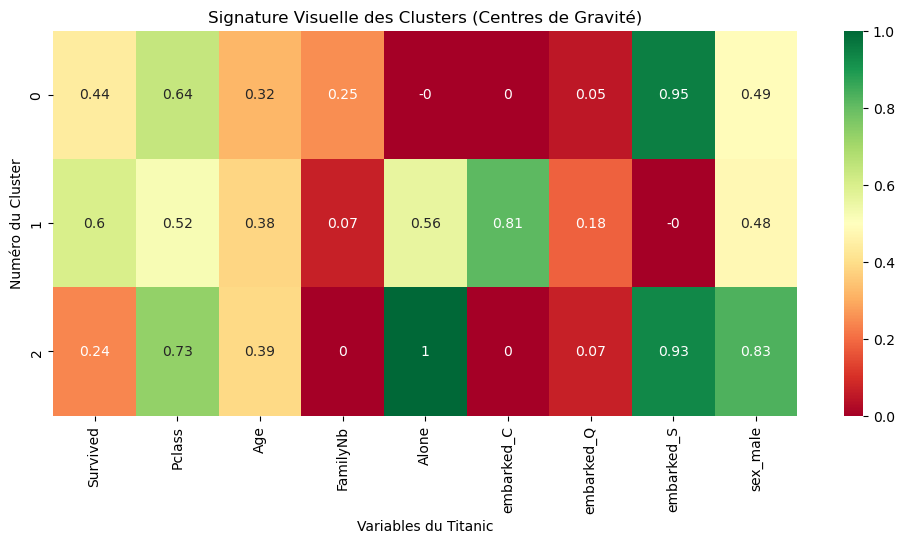

In [16]:
# On utilise les colonnes de titanic_df_scaled pour garantir la correspondance (Shape 3,9)
centers_df = pd.DataFrame(clusterAlgo.cluster_centers_, columns=titanic_df_scaled.columns)

# Affichage des centres avec arrondi pour éliminer le bruit numérique (e-16)
print("=== Profils types des Clusters (Centres de gravité) ===")
print(centers_df.round(2))

import seaborn as sns
import matplotlib.pyplot as plt

# Configuration visuelle
plt.figure(figsize=(12, 5))
sns.heatmap(centers_df.round(2), annot=True, cmap='RdYlGn', center=0.5)

plt.title("Signature Visuelle des Clusters (Centres de Gravité)")
plt.ylabel("Numéro du Cluster")
plt.xlabel("Variables du Titanic")
plt.show()

C:\Users\solta\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\solta\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\solta\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\solta\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

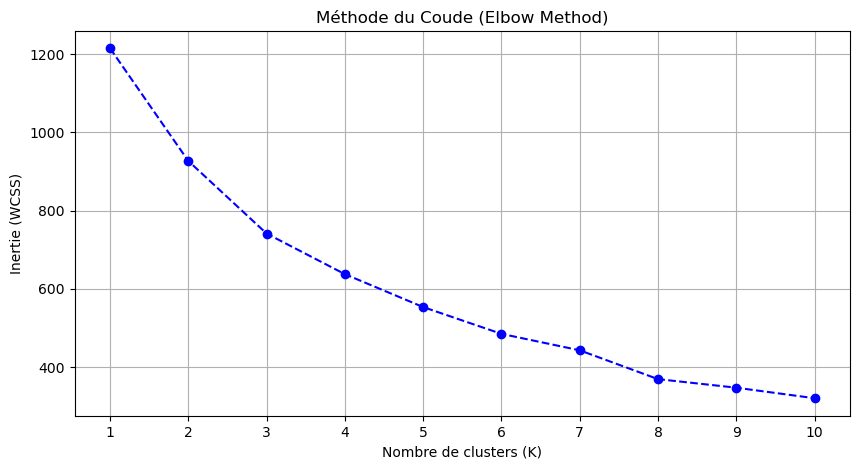

In [17]:
# ==============================================================================
# TITRE : VALIDATION DU NOMBRE OPTIMAL DE CLUSTERS (ELBOW METHOD)
# ==============================================================================
# OBJECTIF : Déterminer mathématiquement le point d'inflexion (le "coude") où
# l'ajout d'un nouveau cluster n'apporte plus de réduction significative de
# l'inertie. Cela permet d'éviter le sur-apprentissage (overfitting).
# ==============================================================================

import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

wcss = []

# ATTENTION : On utilise titanic_df_scaled pour que le graphique soit cohérent
# avec votre modèle final.
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', n_init='auto', random_state=42)
    kmeans.fit(titanic_df_scaled.drop(columns=['label', 'Cluster'], errors='ignore'))
    wcss.append(kmeans.inertia_)

# Affichage du graphique
plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--', color='b')
plt.title('Méthode du Coude (Elbow Method)')
plt.xlabel('Nombre de clusters (K)')
plt.ylabel('Inertie (WCSS)')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

In [18]:
from sklearn.metrics import silhouette_score

score = silhouette_score(titanic_df_scaled.drop(columns=['label', 'Cluster'], errors='ignore'), clusterAlgo.labels_)

print(f"Silhouette Score pour K=3 : {score:.3f}")

Silhouette Score pour K=3 : 0.306


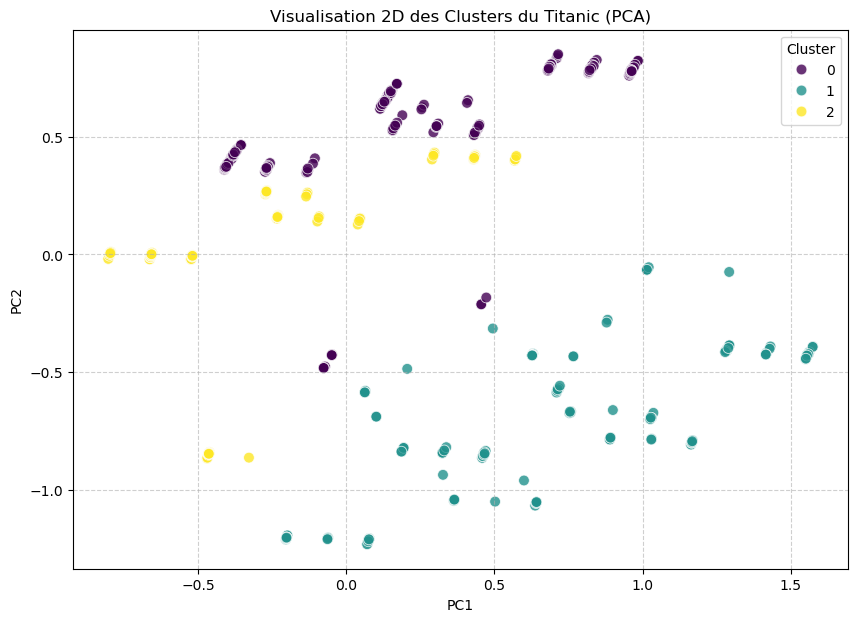

In [19]:
# Analyse PCA
from sklearn.decomposition import PCA
import seaborn as sns

# 1. Configuration de la PCA pour 2 composants
pca = PCA(n_components=2)
pca_data = pca.fit_transform(titanic_df_scaled.drop(columns=['label', 'Cluster'], errors='ignore'))

# 2. Création d'un DataFrame temporaire pour Seaborn
pca_df = pd.DataFrame(pca_data, columns=['PC1', 'PC2'])
pca_df['label'] = clusterAlgo.labels_

# 3. Affichage du graphique
plt.figure(figsize=(10, 7))
sns.scatterplot(x='PC1', y='PC2', hue='label', data=pca_df, palette='viridis', s=60, alpha=0.8)
plt.title('Visualisation 2D des Clusters du Titanic (PCA)')
plt.legend(title='Cluster')
plt.grid(True, linestyle='--', alpha=0.6)
# Sauvegarde du graphique en haute résolution (300 DPI)
plt.show()

In [20]:
# TITRE : CLUSTERING PAR DENSITÉ (DBSCAN)
# OBJECTIF : Identifier des groupes de forme arbitraire et détecter les valeurs aberrantes (outliers).


from sklearn.cluster import DBSCAN

# 1. Configuration
# eps : Le rayon de voisinage (distance max entre deux points)
# min_samples : Le nombre minimum de points pour former un "cœur" de cluster
dbscan = DBSCAN(eps=0.5, min_samples=5)

# 2. Entraînement sur les données normalisées
# On retire la colonne 'label' créée par le K-Means pour ne pas polluer l'algorithme
db_labels = dbscan.fit_predict(titanic_df_scaled.drop(columns=['label', 'Cluster'], errors='ignore'))

# 3. Intégration des résultats
titanic_df['dbscan_label'] = db_labels

# 4. Premier bilan des clusters trouvés
print("RÉPARTITION DES CLUSTERS DBSCAN")
print(titanic_df['dbscan_label'].value_counts())

RÉPARTITION DES CLUSTERS DBSCAN
dbscan_label
 4     273
 0      91
 3      87
 2      53
 8      48
 11     46
 9      39
 5      27
-1      27
 1      25
 10     21
 17     18
 7      17
 22     17
 6      16
 24     11
 12     10
 14      9
 18      9
 23      8
 20      7
 25      6
 13      6
 21      5
 19      5
 16      5
 15      5
Name: count, dtype: int64


In [21]:
# ANALYSE DES OUTLIERS (BRUIT) DÉTECTÉS PAR DBSCAN soit 27


# On isole le bruit
outliers = titanic_df[titanic_df['dbscan_label'] == -1]

print(f"Nombre d'outliers détectés : {len(outliers)}")
print("\n APERÇU DES 5 PREMIERS OUTLIERS ")
# On affiche quelques colonnes clés pour comprendre l'atypisme
cols_interet = ['Survived', 'Pclass', 'Age', 'FamilyNb', 'Alone']
print(outliers[cols_interet].head())

print("\n=== STATISTIQUES DES OUTLIERS ===")
print(outliers[cols_interet].describe())

Nombre d'outliers détectés : 27

 APERÇU DES 5 PREMIERS OUTLIERS 
     Survived  Pclass        Age  FamilyNb  Alone
19          1       3  29.699118         0      1
41          0       2  27.000000         1      0
61          1       1  38.000000         0      1
114         0       3  17.000000         0      1
177         0       1  50.000000         0      1

=== STATISTIQUES DES OUTLIERS ===
        Survived     Pclass        Age   FamilyNb      Alone
count  27.000000  27.000000  27.000000  27.000000  27.000000
mean    0.481481   2.148148  31.018355   0.962963   0.555556
std     0.509175   0.818239  15.248521   1.315046   0.506370
min     0.000000   1.000000   1.000000   0.000000   0.000000
25%     0.000000   1.500000  24.000000   0.000000   0.000000
50%     0.000000   2.000000  29.699118   0.000000   1.000000
75%     1.000000   3.000000  38.500000   2.000000   1.000000
max     1.000000   3.000000  62.000000   5.000000   1.000000


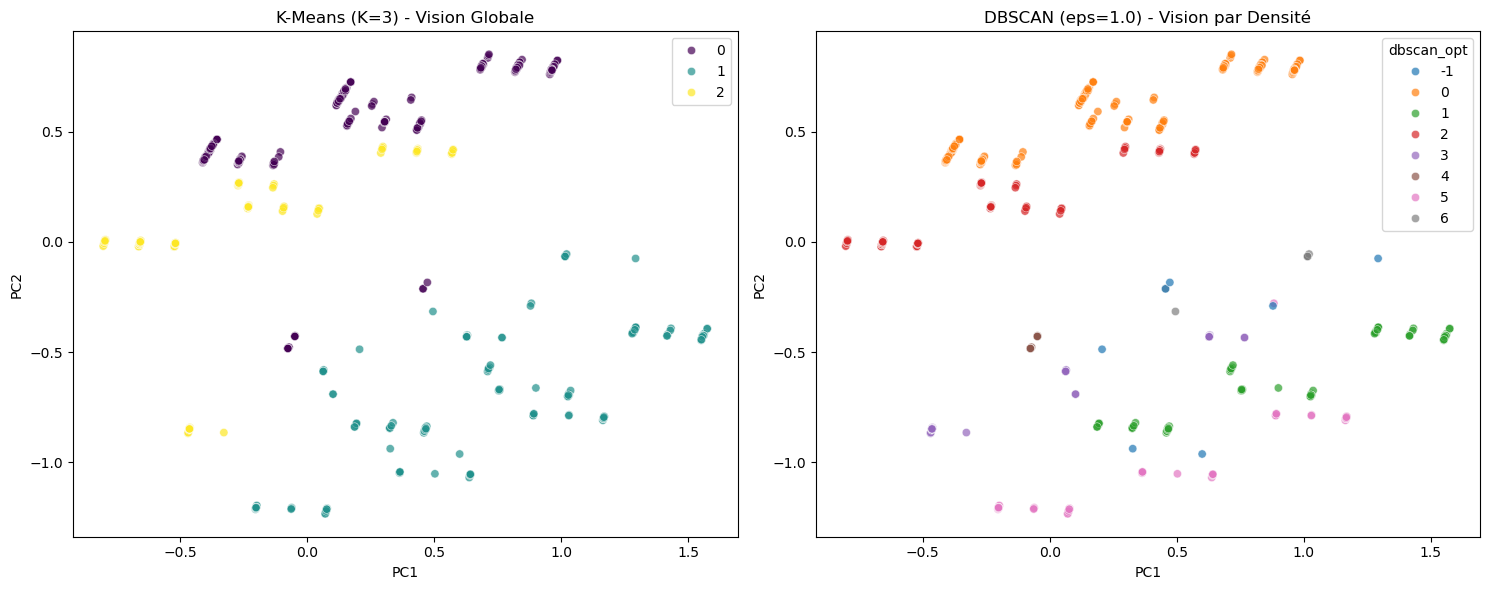

In [23]:
from sklearn.cluster import DBSCAN
import seaborn as sns
import matplotlib.pyplot as plt

# DBSCAN
dbscan = DBSCAN(eps=1.0, min_samples=5)
titanic_df['dbscan_opt'] = dbscan.fit_predict(titanic_df_scaled)

# PCA dataframe
pca_df['dbscan_opt'] = titanic_df['dbscan_opt'].values

# Plot
plt.figure(figsize=(15, 6))

# K-Means
plt.subplot(1, 2, 1)
sns.scatterplot(x='PC1', y='PC2', hue=clusterAlgo.labels_, data=pca_df, palette='viridis', alpha=0.7)
plt.title('K-Means (K=3) - Vision Globale')

# DBSCAN
plt.subplot(1, 2, 2)
sns.scatterplot(x='PC1', y='PC2', hue='dbscan_opt', data=pca_df, palette='tab10', alpha=0.7)
plt.title('DBSCAN (eps=1.0) - Vision par Densité')

plt.tight_layout()
plt.show()